In [2]:
import pandas as pd
import xml.etree.ElementTree as ET

# Parsear el XML
tree = ET.parse('data/raw/prices.xml')
root = tree.getroot()

# Convertir a DataFrame
registros = []
for place in root.findall('place'):
    place_id = place.get('place_id')
    precios = {'place_id': place_id}
    for gas in place.findall('gas_price'):
        precios[gas.get('type')] = float(gas.text) if gas.text else None
    registros.append(precios)

df = pd.DataFrame(registros)
print(f"Total estaciones: {len(df)}")
df.head(10)

Total estaciones: 16425


,place_id,regular,premium,diesel
0,11703,22.95,27.90,NaN
1,11702,24.70,30.30,27.99
2,11701,20.49,NaN,27.69
3,11700,23.58,27.85,27.90
4,11699,NaN,27.45,NaN
5,11699,22.29,NaN,NaN
6,11697,NaN,NaN,27.99
7,11697,23.99,27.79,NaN
8,11696,22.15,27.50,26.50
9,11695,23.99,27.79,28.49


In [3]:
# Estadísticas generales
print("=== ESTADÍSTICAS DE PRECIOS ===\n")
print(df[['regular', 'premium', 'diesel']].describe().round(2))

print("\n=== VALORES NULOS (estaciones sin ese combustible) ===")
print(df.isnull().sum())

print("\n=== RANGO DE PRECIOS ===")
for col in ['regular', 'premium', 'diesel']:
    print(f"{col}: min=${df[col].min()} | max=${df[col].max()} | diferencia=${round(df[col].max()-df[col].min(),2)}")

=== ESTADÍSTICAS DE PRECIOS ===

        regular   premium    diesel
count  13555.00  12816.00  10416.00
mean      23.66     28.39     27.70
std        1.06      1.37      1.12
min        0.01      0.01      0.01
25%       23.69     27.97     27.00
50%       23.99     28.59     27.99
75%       23.99     29.19     28.00
max       29.98     31.36     31.50

=== VALORES NULOS (estaciones sin ese combustible) ===
place_id       0
regular     2870
premium     3609
diesel      6009
dtype: int64

=== RANGO DE PRECIOS ===
regular: min=$0.01 | max=$29.98 | diferencia=$29.97
premium: min=$0.01 | max=$31.36 | diferencia=$31.35
diesel: min=$0.01 | max=$31.5 | diferencia=$31.49


Estaciones con precio regular válido: 13550
Registros eliminados por precio inválido: 5


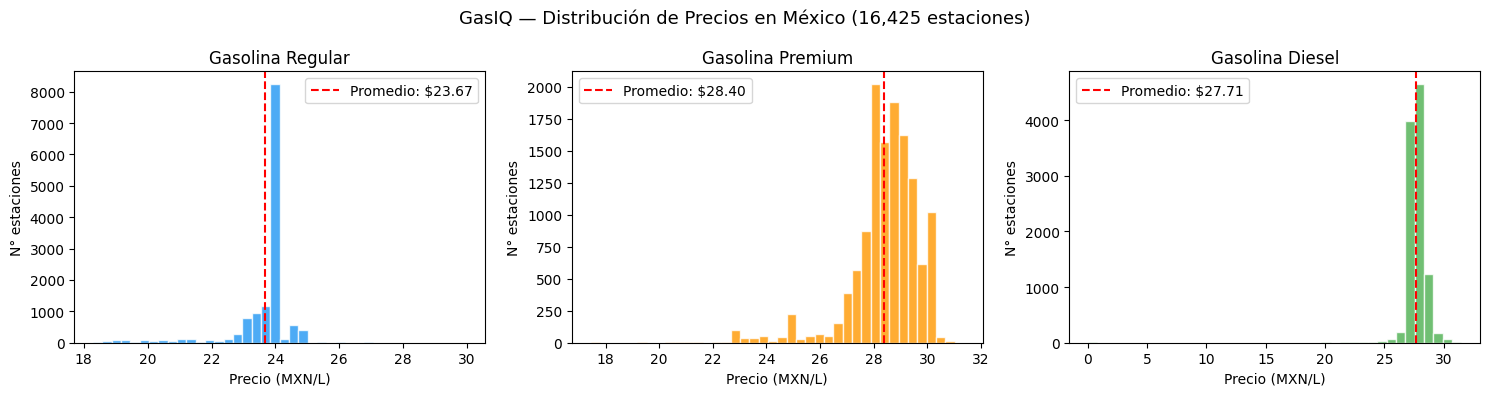

In [6]:
import os
os.makedirs('data/processed', exist_ok=True)
import matplotlib.pyplot as plt

# Filtrar precios erróneos (menos de 15 pesos es imposible)
df_limpio = df[
    (df['regular'] > 15) | df['regular'].isna()
].copy()

print(f"Estaciones con precio regular válido: {df_limpio['regular'].notna().sum()}")
print(f"Registros eliminados por precio inválido: {len(df) - len(df_limpio)}")

# Gráfica de distribución de precios
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('GasIQ — Distribución de Precios en México (16,425 estaciones)', fontsize=13)

colores = ['#2196F3', '#FF9800', '#4CAF50']
for ax, col, color in zip(axes, ['regular', 'premium', 'diesel'], colores):
    data = df_limpio[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Gasolina {col.capitalize()}')
    ax.set_xlabel('Precio (MXN/L)')
    ax.set_ylabel('N° estaciones')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Promedio: ${data.mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig('data/processed/distribucion_precios.png', dpi=150)
plt.show()

In [7]:
# Top 10 precios más baratos y más caros (gasolina regular)
df_regular = df_limpio[df_limpio['regular'].notna()].copy()

print("=== 10 ESTACIONES MÁS BARATAS (Regular) ===")
print(df_regular.nsmallest(10, 'regular')[['place_id', 'regular', 'premium', 'diesel']].to_string())

print("\n=== 10 ESTACIONES MÁS CARAS (Regular) ===")
print(df_regular.nlargest(10, 'regular')[['place_id', 'regular', 'premium', 'diesel']].to_string())

print(f"\n=== CONCLUSIÓN CLAVE ===")
diff = df_regular['regular'].max() - df_regular['regular'].min()
print(f"Diferencia máxima en gasolina regular: ${diff:.2f} MXN/L")
print(f"Si llenas 40L en la más cara vs más barata: ${diff*40:.2f} MXN de diferencia")
print(f"Al año (tanque semanal): ${diff*40*52:.2f} MXN de diferencia")

=== 10 ESTACIONES MÁS BARATAS (Regular) ===
     place_id  regular  premium  diesel
1307     2171    18.29    23.29     NaN
1411     2306    18.29    23.29     NaN
1461     2088    18.29    23.29   26.39
1471     2394    18.29    23.29   26.39
1599     2168    18.29    23.29   26.39
1613     2366    18.29    23.29     NaN
1823     2250    18.29    23.29     NaN
4869     5312    18.45    22.85   26.97
862     10003    18.58      NaN     NaN
891      9984    18.58      NaN     NaN

=== 10 ESTACIONES MÁS CARAS (Regular) ===
      place_id  regular  premium  diesel
2639      8694    29.98      NaN     NaN
16049    11575    29.20      NaN     NaN
8414      4554    28.79    28.89   27.89
8109     10881    28.59    28.29   27.99
10622     3922    28.09      NaN     NaN
37       11383    27.99      NaN     NaN
12376    22652    27.60    28.55   27.30
15687    12750    27.56    28.43   28.70
12533    22321    27.50      NaN     NaN
6425      6959    27.00      NaN   31.50

=== CONCLUSIÓN CLAVE 